# Super-Resolution of 2D Darcy Flow using Fourier Neural Operators
**Scientific Machine Learning, Mines Paris PSL / SPEIT 2026**

**Darcy Flow PDE:**

$$-\nabla \cdot (a(x,y)\,\nabla u(x,y)) = f(x,y) \quad (x,y)\in [0,1]^2$$

$$u = 0 \quad \text{on } \partial[0,1]^2$$

**Operator learned:**

$$\mathcal{G}_\theta : \bigl(a(x,y),\, u_{LR}(x,y)\bigr) \longrightarrow u_{HR}(x,y) \quad (\times 4 \text{ upsampling})$$

**Models compared:** CNN | FNO-8 | FNO-16

## 0 - Installation

In [44]:
!pip install -q torch numpy scipy matplotlib pandas
print('packages ready')

packages ready


## 1 - Configuration

In [45]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import cg

# Hyperparameters
SEED = 42
N_TRAIN = 800
N_TEST = 200
HR_SIZE = 64      # HR grid size
LR_SIZE = 16      # LR grid size (scale = 4)
SCALE = HR_SIZE // LR_SIZE
BATCH_SIZE = 16
EPOCHS = 200      # Li et al. use 500; 200 is a good compromise
LR_RATE = 1e-3    # Li et al. use 1e-3
FORCE_VALUE = 1.0

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)

print(f'device  : {DEVICE}')
print(f'HR={HR_SIZE}  LR={LR_SIZE}  scale=x{SCALE}')
print(f'epochs={EPOCHS}  batch={BATCH_SIZE}  lr={LR_RATE}')

device  : cpu
HR=64  LR=16  scale=x4
epochs=200  batch=16  lr=0.001


## Dataset Generation

The coefficient field $a(x,y)$ is piecewise heterogeneous: $a \in \{3, 12\}$ (two-material, high/low permeability), generated via a thresholded Gaussian random field.

Each model receives a **2-channel input** $(B, 2, H, W)$:

- Channel 0 : $a(x,y)$ — the physical coefficient of the Darcy problem
- Channel 1 : $u_{LR}(x,y)$ — the low-resolution solution (bicubic ×4 upsampling)

Target: $u_{HR}(x,y)$ on a $64 \times 64$ grid.

In [46]:
def gaussian_filter(arr, sigma):
    size = max(1, int(4 * sigma + 0.5)) * 2 + 1
    x = np.arange(size) - size // 2
    k = np.exp(-x ** 2 / (2 * sigma ** 2))
    k /= k.sum()
    arr = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 0, arr)
    arr = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 1, arr)
    return arr


def generate_coefficient_field(n, smooth_sigma=3.0, threshold=0.0):
    noise = np.random.randn(n, n)
    smooth = gaussian_filter(noise, sigma=smooth_sigma)
    smooth = (smooth - smooth.mean()) / (smooth.std() + 1e-8)
    return np.where(smooth > threshold, 12.0, 3.0).astype(np.float64)


def solve_darcy(a, f_value=1.0):
    n = a.shape[0]
    h = 1.0 / (n - 1)
    N = (n - 2) * (n - 2)
    A = lil_matrix((N, N), dtype=np.float64)
    b = np.ones(N, dtype=np.float64) * f_value

    def idx(i, j):
        return (i - 1) * (n - 2) + (j - 1)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            row = idx(i, j)
            a_e = 0.5 * (a[i, j] + a[i + 1, j])
            a_w = 0.5 * (a[i, j] + a[i - 1, j])
            a_n = 0.5 * (a[i, j] + a[i, j + 1])
            a_s = 0.5 * (a[i, j] + a[i, j - 1])
            center = (a_e + a_w + a_n + a_s) / h ** 2
            A[row, row] = center
            if i + 1 < n - 1: A[row, idx(i + 1, j)] = -a_e / h ** 2
            if i - 1 > 0: A[row, idx(i - 1, j)] = -a_w / h ** 2
            if j + 1 < n - 1: A[row, idx(i, j + 1)] = -a_n / h ** 2
            if j - 1 > 0: A[row, idx(i, j - 1)] = -a_s / h ** 2

    u_int, _ = cg(A.tocsr(), b, atol=1e-10)
    u = np.zeros((n, n), dtype=np.float64)
    for i in range(1, n - 1):
        for j in range(1, n - 1):
            u[i, j] = u_int[idx(i, j)]
    return u.astype(np.float32)


def generate_dataset(n_samples, hr_size):
    coeffs, solutions = [], []
    for k in range(n_samples):
        a = generate_coefficient_field(hr_size)
        u = solve_darcy(a, FORCE_VALUE)
        coeffs.append(a)
        solutions.append(u)
        if (k + 1) % 200 == 0:
            print(f'  {k + 1}/{n_samples}')
    return np.stack(coeffs).astype(np.float32), np.stack(solutions)


if os.path.exists('data/sol_train.npy'):
    print('loading dataset from disk...')
    coeff_train = np.load('data/coeff_train.npy')
    sol_train = np.load('data/sol_train.npy')
    coeff_test = np.load('data/coeff_test.npy')
    sol_test = np.load('data/sol_test.npy')
else:
    print('generating train set...')
    coeff_train, sol_train = generate_dataset(N_TRAIN, HR_SIZE)
    print('generating test set...')
    coeff_test, sol_test = generate_dataset(N_TEST, HR_SIZE)
    np.save('data/coeff_train.npy', coeff_train)
    np.save('data/sol_train.npy', sol_train)
    np.save('data/coeff_test.npy', coeff_test)
    np.save('data/sol_test.npy', sol_test)
    print('dataset saved to disk')

print(f'train : coeff={coeff_train.shape}  sol={sol_train.shape}')
print(f'test  : coeff={coeff_test.shape}   sol={sol_test.shape}')

loading dataset from disk...
train : coeff=(800, 64, 64)  sol=(800, 64, 64)
test  : coeff=(200, 64, 64)   sol=(200, 64, 64)


## Input Construction

In [47]:
u_mean = sol_train.mean()
u_std = sol_train.std() + 1e-8
a_mean = float(coeff_train.mean())
a_std = float(coeff_train.std()) + 1e-8

def normalize_u(u): return (u - u_mean) / u_std
def denormalize_u(u): return u * u_std + u_mean

sol_train_n = normalize_u(sol_train)
sol_test_n = normalize_u(sol_test)


def build_inputs(solutions, coeffs):
    x = torch.tensor(solutions[:, None], dtype=torch.float32)
    a = torch.tensor(coeffs[:, None], dtype=torch.float32)
    lr = F.interpolate(x, size=(LR_SIZE, LR_SIZE), mode='area')
    lr_up = F.interpolate(lr, size=(HR_SIZE, HR_SIZE),
                          mode='bicubic', align_corners=False)
    a_norm = (a - a_mean) / a_std
    inp = torch.cat([a_norm, lr_up], dim=1).numpy()
    return inp, x.numpy()[:, 0]

x_train, y_train = build_inputs(sol_train_n, coeff_train)
x_test, y_test = build_inputs(sol_test_n, coeff_test)

print(f'a : mean={a_mean:.3f}  std={a_std:.3f}')
print(f'u : mean={u_mean:.4f}  std={u_std:.4f}')
print(f'input shape : {x_train.shape}  (B, 2, H, W)')
print(f'target shape: {y_train.shape}  (B, H, W)')

a : mean=7.493  std=4.500
u : mean=0.0054  std=0.0036
input shape : (800, 2, 64, 64)  (B, 2, H, W)
target shape: (800, 64, 64)  (B, H, W)


## Dataset Visualization

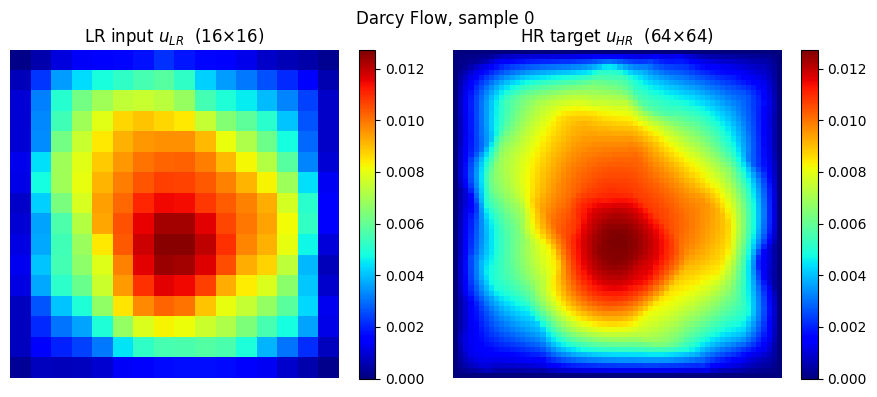

In [48]:
lr_native = denormalize_u(
    F.interpolate(
        torch.tensor(sol_train_n[0:1, None], dtype=torch.float32),
        size=(LR_SIZE, LR_SIZE), mode='area'
    )[0, 0].numpy()
)
hr_vis = denormalize_u(y_train[0])
vmin, vmax = min(lr_native.min(), hr_vis.min()), max(lr_native.max(), hr_vis.max())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Darcy Flow, sample 0', fontsize=12)

im1 = axes[0].imshow(lr_native, cmap='jet', vmin=vmin, vmax=vmax,
                     interpolation='nearest')
axes[0].set_title(f'LR input $u_{{LR}}$  ({LR_SIZE}×{LR_SIZE})')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(hr_vis, cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_title(f'HR target $u_{{HR}}$  ({HR_SIZE}×{HR_SIZE})')
plt.colorbar(im2, ax=axes[1])

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('results/dataset_example.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 - PyTorch Dataset and Metrics

In [49]:
class DarcyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y[:, None], dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]


train_ds = DarcyDataset(x_train, y_train)
test_ds = DarcyDataset(x_test, y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


def relative_l2(pred, target):
    num = torch.norm(pred - target)
    den = torch.norm(target) + 1e-8
    return (num / den).item()


def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()


def psnr(pred, target):
    p_d = denormalize_u(pred.detach().cpu().numpy())
    t_d = denormalize_u(target.detach().cpu().numpy())
    dr = t_d.max() - t_d.min()
    return 20 * np.log10(dr / (np.sqrt(np.mean((p_d - t_d) ** 2)) + 1e-12))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5 - Architecture

Both models receive the 2-channel input $[a(x,y),\, u_{LR}(x,y)]$.
Including $a$ gives each model direct access to the physical structure of the problem.

### FNO-2D
The spatial grid $(x_{coord}, y_{coord})$ is appended, giving a 4-feature token per point:
$$[a,\; u_{LR},\; x_{coord},\; y_{coord}] \quad \Rightarrow \quad \text{fc0} : \mathbb{R}^4 \to \mathbb{R}^W$$
Fourier layer:
$$v_{t+1}(x) = \sigma\left(W v_t + \mathcal{F}^{-1}[R \cdot \mathcal{F}(v_t)](x)\right)$$
FNO-8 uses $k_{max}=8$ modes, FNO-16 uses $k_{max}=16$.

### CNN Baseline (SRCNN)
Same 2-channel input, purely local convolutions — no global spectral operations.

In [50]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        s = 1.0 / (in_ch * out_ch)
        self.w1 = nn.Parameter(
            s * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.w2 = nn.Parameter(
            s * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def forward(self, x):
        B = x.shape[0]
        xf = torch.fft.rfft2(x)
        out = torch.zeros(B, self.w1.shape[1],
                          x.size(-2), x.size(-1) // 2 + 1,
                          dtype=torch.cfloat, device=x.device)
        m1, m2 = self.modes1, self.modes2
        out[:, :, :m1, :m2] = torch.einsum(
            'bixy,ioxy->boxy', xf[:, :, :m1, :m2], self.w1)
        out[:, :, -m1:, :m2] = torch.einsum(
            'bixy,ioxy->boxy', xf[:, :, -m1:, :m2], self.w2)
        return torch.fft.irfft2(out, s=(x.size(-2), x.size(-1)))


class FNO2d(nn.Module):
    
    def __init__(self, modes1=12, modes2=12, width=32):
        super().__init__()
        self.fc0 = nn.Linear(4, width)   # (a, u_LR, x, y) -> width
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def get_grid(self, shape, device):
        B, _, H, W = shape
        gx = torch.linspace(0, 1, H, device=device)
        gy = torch.linspace(0, 1, W, device=device)
        gx = gx.reshape(1, H, 1, 1).repeat(B, 1, W, 1)
        gy = gy.reshape(1, 1, W, 1).repeat(B, H, 1, 1)
        return torch.cat((gx, gy), dim=-1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        # x shape: (B, 2, H, W) -> permute -> (B, H, W, 2)
        # grid shape: (B, H, W, 2)
        # cat -> (B, H, W, 4) : [a, u_LR, x_coord, y_coord]
        x = torch.cat((x.permute(0, 2, 3, 1), grid), dim=-1)
        x = self.fc0(x).permute(0, 3, 1, 2)
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))
        x = x.permute(0, 2, 3, 1)
        x = F.gelu(self.fc1(x))
        return self.fc2(x).permute(0, 3, 1, 2)


class SRCNN(nn.Module):
    """CNN baseline -- local conv only, no spectral operations."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 9, padding=4), nn.ReLU(),
            nn.Conv2d(64, 64, 5, padding=2), nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1))

    def forward(self, x):
        return self.net(x)


# sanity check
_x = torch.randn(2, 2, HR_SIZE, HR_SIZE)
_f8 = FNO2d(8, 8, 32)
_f16 = FNO2d(16, 16, 32)
_cnn = SRCNN()
print(f'FNO-8   {tuple(_x.shape)} -> {tuple(_f8(_x).shape)}'
      f'  params={count_params(_f8):,}')
print(f'FNO-16  {tuple(_x.shape)} -> {tuple(_f16(_x).shape)}'
      f'  params={count_params(_f16):,}')
print(f'CNN     {tuple(_x.shape)} -> {tuple(_cnn(_x).shape)}'
      f'  params={count_params(_cnn):,}')

FNO-8   (2, 2, 64, 64) -> (2, 1, 64, 64)  params=533,025
FNO-16  (2, 2, 64, 64) -> (2, 1, 64, 64)  params=2,105,889
CNN     (2, 2, 64, 64) -> (2, 1, 64, 64)  params=131,649


## 6 - Training

**Loss:** MSE  
**Optimizer:** Adam + StepLR halved every 50 epochs

In [51]:
def train_model(model, name):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=50, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    best_loss, best_state = float('inf'), None
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr = 0.0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()

            loss = criterion(model(x), y)

            loss.backward()
            optimizer.step()

            tr += loss.item() * len(x)

        tr /= N_TRAIN

        scheduler.step()

        model.eval()
        te, rl2_vals, psnr_vals = 0.0, [], []

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                p = model(x)

                te += criterion(p, y).item() * len(x)

                rl2_vals.append(
                    relative_l2(p.cpu(), y.cpu())
                )

                psnr_vals.append(
                    psnr(p.cpu(), y.cpu())
                )

        te /= N_TEST

        te_rl2 = np.mean(rl2_vals)
        te_psnr = np.mean(psnr_vals)

        train_losses.append(tr)
        test_losses.append(te)

        if te < best_loss:
            best_loss = te
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        if epoch % 50 == 0 or epoch == 1:
            print(f'  [{name}] epoch {epoch:3d}/{EPOCHS}'
                  f'  train={tr:.6f}'
                  f'  test={te:.6f}'
                  f'  RL2={te_rl2:.4f}'
                  f'  PSNR={te_psnr:.2f}dB'
                  f'  lr={optimizer.param_groups[0]["lr"]:.1e}'
                  f'  t={time.time() - t0:.0f}s')

    model.load_state_dict(best_state)

    print(f'  [{name}] best test MSE={best_loss:.6f}')

    return model, train_losses, test_losses

In [ ]:
print('CNN Baseline: \n')
cnn, cnn_tr, cnn_te = train_model(SRCNN(), 'CNN')
torch.save(cnn.state_dict(), 'data/cnn.pt')

print()
print('FNO-8  (kmax=8): \n')
fno8, fno8_tr, fno8_te = train_model(FNO2d(8, 8, 32), 'FNO-8')
torch.save(fno8.state_dict(), 'data/fno8.pt')

print()
print('FNO-16  (kmax=16): \n')
fno16, fno16_tr, fno16_te = train_model(FNO2d(16, 16, 32), 'FNO-16')
torch.save(fno16.state_dict(), 'data/fno16.pt')

CNN Baseline: 

  [CNN] epoch   1/200  train=0.102911  test=0.008632  RL2=0.0934  PSNR=31.70dB  lr=1.0e-03  t=12s


KeyboardInterrupt: 

## 7 - Results

In [ ]:
ep_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.semilogy(ep_range, cnn_te, label='CNN', lw=2, ls='--')
plt.semilogy(ep_range, fno8_te, label='FNO-8', lw=2)
plt.semilogy(ep_range, fno16_te, label='FNO-16', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Test MSE (log scale)')
plt.title('Validation loss')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('results/loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def evaluate_model(model):
    model.eval()
    model.to(DEVICE)
    rl2, rm, rp = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model(x)
            rl2.append(relative_l2(p.cpu(), y.cpu()))
            rm.append(rmse(p.cpu(), y.cpu()))
            rp.append(psnr(p.cpu(), y.cpu()))
    elapsed = time.time() - t0
    return {
        'Relative L2': np.mean(rl2),
        'RMSE': np.mean(rm),
        'PSNR': np.mean(rp),
        'Inference (ms)': elapsed / N_TEST * 1000,
    }


results = {
    'CNN': evaluate_model(cnn),
    'FNO-8': evaluate_model(fno8),
    'FNO-16': evaluate_model(fno16),
}

param_map = {
    'CNN': count_params(cnn),
    'FNO-8': count_params(fno8),
    'FNO-16': count_params(fno16),
}

df = pd.DataFrame(results).T
df.insert(0, 'Params', [param_map[m] for m in df.index])
df = df.sort_values('Relative L2')
df.to_csv('results/metrics.csv')

print('=' * 65)
print('QUANTITATIVE RESULTS : test set')
print('=' * 65)
print(df.to_string())
print(f'\nbest model : {df.index[0]}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Quantitative comparison', fontsize=13)

colors = ['blue', 'orange', 'green']

df['Relative L2'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_ylabel('Relative L2 (lower is better)')
axes[0].set_title('Relative L2 error')
axes[0].grid(axis='y', alpha=0.4)
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9)

df['PSNR'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_ylabel('PSNR dB (higher is better)')
axes[1].set_title('PSNR')
axes[1].grid(axis='y', alpha=0.4)
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Qualitative comparison

In [ ]:
def get_preds(idx):
    x, y = test_ds[idx]
    xb = x[None].to(DEVICE)
    with torch.no_grad():
        pc  = cnn(xb).cpu()[0, 0].numpy()
        pf8  = fno8(xb).cpu()[0, 0].numpy()
        pf16 = fno16(xb).cpu()[0, 0].numpy()
    return pc, pf8, pf16, y[0].numpy()


titles = ['HR target', 'CNN', 'FNO-8', 'FNO-16']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Qualitative comparison', fontsize=13)

for row in range(3):
    pc, pf8, pf16, hr = get_preds(row * (N_TEST // 3))
    imgs = [denormalize_u(hr), denormalize_u(pc),
            denormalize_u(pf8), denormalize_u(pf16)]
    vmin, vmax = imgs[0].min(), imgs[0].max()
    for col, (img, title) in enumerate(zip(imgs, titles)):
        im = axes[row, col].imshow(img, cmap='jet', vmin=vmin, vmax=vmax)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title, fontsize=10)
    plt.colorbar(im, ax=axes[row, :], fraction=0.015, pad=0.02)

plt.tight_layout()
plt.savefig('results/qualitative.png', dpi=150, bbox_inches='tight')
plt.show()

### Error maps

In [ ]:
pc, pf8, pf16, hr = get_preds(0)
hr_d = denormalize_u(hr)
errors = {
    'CNN': np.abs(denormalize_u(pc) - hr_d),
    'FNO-8': np.abs(denormalize_u(pf8) - hr_d),
    'FNO-16': np.abs(denormalize_u(pf16) - hr_d),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Absolute error maps, sample 0', fontsize=12)
vmax_e = max(e.max() for e in errors.values())
for ax, (name, err) in zip(axes, errors.items()):
    im = ax.imshow(err, cmap='magma', vmin=0, vmax=vmax_e)
    ax.set_title(f'{name}  (max={err.max():.4f})', fontsize=9)
    ax.axis('off')
plt.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
plt.tight_layout()
plt.savefig('results/error_maps.png', dpi=150, bbox_inches='tight')
plt.show()